In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot
import seaborn as sns
from matplotlib import pyplot as plt

In [14]:
df=pd.read_csv("Advertising.csv")

In [15]:
X=df.drop("sales",axis=1)
y=df["sales"]

In [16]:
from sklearn.preprocessing import PolynomialFeatures

In [17]:
polynomial_converter=PolynomialFeatures(degree=2,include_bias=False)

In [18]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [19]:
polynomial_converter.fit(X)

,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


In [20]:
poly_feature=polynomial_converter.transform(X)

In [21]:
poly_feature[0]

array([2.301000e+02, 3.780000e+01, 6.920000e+01, 5.294601e+04,
       8.697780e+03, 1.592292e+04, 1.428840e+03, 2.615760e+03,
       4.788640e+03])

In [7]:
from sklearn.model_selection import train_test_split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(poly_feature, y, test_size=0.3, random_state=101)

In [8]:
from sklearn.linear_model import LinearRegression

In [23]:
model=LinearRegression()

In [24]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
test_prediction=model.predict(X_test)

In [6]:
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [26]:
mae=mean_absolute_error(y_test,test_prediction)
mse=mean_squared_error(y_test,test_prediction)
rmse=np.sqrt(mse)


In [27]:
mae,mse,rmse

(0.4896798044803838, 0.4417505510403753, np.float64(0.6646431757269274))

In [28]:
model.coef_

array([ 5.17095811e-02,  1.30848864e-02,  1.20000085e-02, -1.10892474e-04,
        1.14212673e-03, -5.24100082e-05,  3.34919737e-05,  1.46380310e-04,
       -3.04715806e-05])

In [30]:
test_rmse=[]
train_rmse=[]
for d in range(1,10):
    polynomial_converter=PolynomialFeatures(degree=d,include_bias=False)
    poly_feature=polynomial_converter.fit_transform(X)
    model=LinearRegression()
    X_train, X_test, y_train, y_test = train_test_split(poly_feature, y, test_size=0.3, random_state=101)
    model.fit(X_train,y_train)
    train_pred=model.predict(X_train)
    test_pred=model.predict(X_test)
    train_rmse.append(np.sqrt(mean_squared_error(y_train, train_pred)))  # ✅
    test_rmse.append(np.sqrt(mean_squared_error(y_test, test_pred)))     # ✅

In [34]:
test_rmse

[np.float64(1.5161519375993877),
 np.float64(0.6646431757269274),
 np.float64(0.5803286825236476),
 np.float64(0.5077742639859423),
 np.float64(2.575825081302852),
 np.float64(9.871410116034689),
 np.float64(41.330566088617964),
 np.float64(3103.1690816455084),
 np.float64(12768.354850329179)]

In [36]:
train_rmse

[np.float64(1.734594124329376),
 np.float64(0.5879574085292232),
 np.float64(0.43393443569020673),
 np.float64(0.35170836883993495),
 np.float64(0.25093430399765837),
 np.float64(0.20953728599482707),
 np.float64(0.22046859152326304),
 np.float64(0.27149790271647406),
 np.float64(0.5132042855932262)]

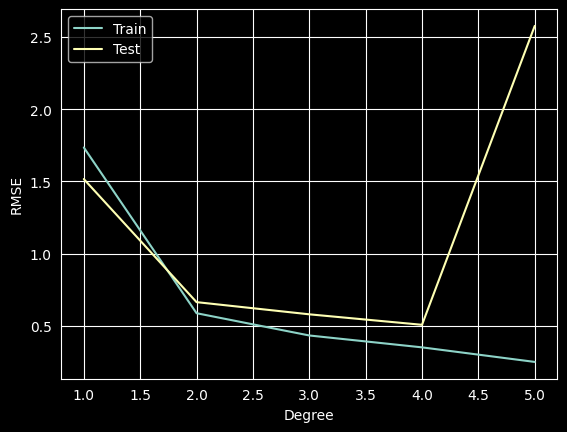

In [42]:
plt.plot(range(1,6),train_rmse[:5])
plt.plot(range(1,6),test_rmse[:5])
plt.xlabel("Degree")
plt.ylabel("RMSE")
plt.legend(["Train","Test"])
plt.show()

# degree 2 or 3 looks ideal

In [44]:
final_poly_converter=PolynomialFeatures(degree=3,include_bias=False)
final_model=LinearRegression()

In [46]:
full_converted_X=final_poly_converter.fit_transform(X)
final_model.fit(full_converted_X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [48]:
from joblib import dump,load

In [50]:
dump(final_model,'final_poly_model.joblib')

['final_poly_model.joblib']

In [52]:
dump(final_poly_converter,"final_poly_converter.joblib")

['final_poly_converter.joblib']

In [54]:
#to load the converter
loaded_converter=load("final_poly_converter.joblib")

In [56]:
#to load model
loaded_model=load("final_poly_model.joblib")

In [58]:
campaign=[[149,22,12]]

In [60]:
transormed=loaded_converter.fit_transform(campaign)
loaded_model.predict(transormed)

array([14.64501014])